# Projekt 6: Wieloagentowe RL na własnym środowisku — Uno (2 graczy)

Cel: spełnić wymagania na 8 punktów z PDF — własne środowisko wieloagentowe (Uno), trening kilku algorytmów RL, porównanie krzywych uczenia, eksperyment same-algorithm vs mixed-algorithms.

**Środowisko**: pełne Uno 2-osobowe (talia 108 kart, wszystkie karty specjalne: Skip, Reverse, +2, Wild, Wild+4), z łańcuchowaniem +2/+4.

**Algorytmy**: MaskablePPO (2 warianty hiperparametrów) i DQN — wszystkie z biblioteki Stable Baselines 3 / sb3-contrib.

**Eksperymenty**:
1. Każdy algorytm trenowany vs random — porównanie krzywych uczenia (na 6 punktów).
2. Self-play PPO (wszyscy agenci ten sam algorytm).
3. Turniej wszystkich modeli (różne algorytmy w tym samym epizodzie).

## 0. Instalacja zależności

W venv masz już `numpy`, `matplotlib`, `gymnasium`, `stable_baselines3`, `torch`, `tensorboard`. Brakuje `sb3-contrib` (potrzebny dla `MaskablePPO`):

```bash
pip install sb3-contrib
```

In [20]:
import os
import random
import time
from copy import deepcopy
from typing import Callable, Optional

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback

from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from sb3_contrib.common.maskable.utils import get_action_masks

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 1. Reprezentacja kart

Indeksujemy 54 unikalne typy kart jednym intem 0–53:
- 0–51: kolorowe karty `kolor * 13 + wartość`, gdzie kolor ∈ {R=0, Y=1, G=2, B=3}, wartość ∈ {0–9, Skip=10, Reverse=11, +2=12}.
- 52: Wild (zmiana koloru).
- 53: Wild+4 (zmiana koloru + przeciwnik dobiera 4).

Pełna talia ma 108 kart: każdy kolor po 1× '0' i 2× pozostałe (25×4 = 100), oraz 4× Wild i 4× Wild+4.

In [21]:
NUM_COLORS = 4
COLOR_NAMES = ['R', 'Y', 'G', 'B']
VALUE_NAMES = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'S', 'Rv', '+2']
NUM_VALUES = len(VALUE_NAMES)  # 13
WILD = 52
WILD_DRAW4 = 53
NUM_CARD_TYPES = 54
NUM_ACTIONS = 59  # 54 play-card + 1 draw + 4 choose-color
DRAW_ACTION = 54
COLOR_ACTION_START = 55  # 55..58 = R,Y,G,B

def card_color(cid: int):
    return None if cid >= 52 else cid // 13

def card_value(cid: int):
    return None if cid >= 52 else cid % 13

def card_name(cid: int) -> str:
    if cid == WILD: return 'Wild'
    if cid == WILD_DRAW4: return 'Wild+4'
    return f'{COLOR_NAMES[cid // 13]}{VALUE_NAMES[cid % 13]}'

def build_deck() -> list:
    deck = []
    for c in range(NUM_COLORS):
        deck.append(c * NUM_VALUES + 0)  # one '0' per color
        for v in range(1, NUM_VALUES):   # two of each other value
            deck.append(c * NUM_VALUES + v)
            deck.append(c * NUM_VALUES + v)
    for _ in range(4):
        deck.append(WILD)
        deck.append(WILD_DRAW4)
    return deck

assert len(build_deck()) == 108
print('Talia OK, 108 kart. Przykład:', [card_name(c) for c in build_deck()[:8]])

Talia OK, 108 kart. Przykład: ['R0', 'R1', 'R1', 'R2', 'R2', 'R3', 'R3', 'R4']


## 2. Silnik gry Uno

Klasa `UnoGame` zawiera całą logikę gry niezależnie od RL. Implementuje:
- rozdanie, dobieranie, odrzucanie, reshuffle gdy stos zakryty się skończy,
- akcje: zagraj kartę (0–53), dobierz (54), wybierz kolor po Wild (55–58),
- karty specjalne: Skip i Reverse w 2-osobowej grze działają tak samo (gracz zachowuje turę),
- łańcuchowanie: +2 można odbić +2, Wild+4 można odbić Wild+4 (house rule),
- maskę legalnych akcji,
- obserwację z perspektywy gracza.

In [22]:
class UnoGame:
    HAND_SIZE = 7
    MAX_TURNS = 2000  # safety cap (długie partie -> remis)

    def __init__(self, rng: Optional[np.random.Generator] = None):
        self.rng = rng if rng is not None else np.random.default_rng()
        self.reset()

    def reset(self):
        self.deck = build_deck()
        self.rng.shuffle(self.deck)
        self.hands = [[], []]
        for _ in range(self.HAND_SIZE):
            for p in range(2):
                self.hands[p].append(self.deck.pop())
        # Initial top card: keep flipping until we get a numeric (0-9) to avoid edge cases
        while True:
            top = self.deck.pop()
            if top < 52 and (top % NUM_VALUES) < 10:
                break
            self.deck.insert(0, top)
        self.discard_top = top
        self.discard_pile: list = []
        self.active_color = top // NUM_VALUES
        self.played_counts = np.zeros(NUM_CARD_TYPES, dtype=np.int32)
        self.played_counts[top] = 1
        self.current_player = 0
        self.draw_debt = 0
        self.need_color_choice = False
        self.done = False
        self.winner: Optional[int] = None
        self.turn_count = 0

    def _draw(self, player: int, n: int):
        for _ in range(n):
            if not self.deck:
                if not self.discard_pile:
                    return
                self.deck = list(self.discard_pile)
                self.discard_pile = []
                self.rng.shuffle(self.deck)
            card = self.deck.pop()
            self.hands[player].append(card)

    def _can_play(self, card: int) -> bool:
        if card >= 52:
            return True
        if card // NUM_VALUES == self.active_color:
            return True
        if self.discard_top < 52 and (card % NUM_VALUES) == (self.discard_top % NUM_VALUES):
            return True
        return False

    def legal_actions(self, player: int) -> np.ndarray:
        mask = np.zeros(NUM_ACTIONS, dtype=bool)
        if self.done or player != self.current_player:
            return mask
        if self.need_color_choice:
            mask[COLOR_ACTION_START:COLOR_ACTION_START + 4] = True
            return mask
        hand_set = set(self.hands[player])
        if self.draw_debt > 0:
            top = self.discard_top
            if top == WILD_DRAW4:
                if WILD_DRAW4 in hand_set:
                    mask[WILD_DRAW4] = True
            elif top < 52 and (top % NUM_VALUES) == 12:  # +2
                for c in hand_set:
                    if c < 52 and (c % NUM_VALUES) == 12:
                        mask[c] = True
            mask[DRAW_ACTION] = True  # accept debt
            return mask
        for c in hand_set:
            if self._can_play(c):
                mask[c] = True
        mask[DRAW_ACTION] = True
        return mask

    def step(self, action: int):
        rewards = [0.0, 0.0]
        if self.done:
            return rewards, True
        self.turn_count += 1
        if self.turn_count > self.MAX_TURNS:
            self.done = True
            return rewards, True
        player = self.current_player
        opponent = 1 - player
        # Color choice
        if self.need_color_choice:
            assert COLOR_ACTION_START <= action < COLOR_ACTION_START + 4
            self.active_color = action - COLOR_ACTION_START
            self.need_color_choice = False
            self.current_player = opponent
            return rewards, self.done
        # Draw / accept debt
        if action == DRAW_ACTION:
            n = self.draw_debt if self.draw_debt > 0 else 1
            self._draw(player, n)
            self.draw_debt = 0
            self.current_player = opponent
            return rewards, self.done
        # Play card
        assert action in self.hands[player], f'Card {action} not in hand'
        self.hands[player].remove(action)
        self.played_counts[action] += 1
        self.discard_pile.append(self.discard_top)
        self.discard_top = action
        if action < 52:
            self.active_color = action // NUM_VALUES
        # Win check
        if len(self.hands[player]) == 0:
            self.winner = player
            self.done = True
            rewards[player] = 1.0
            rewards[opponent] = -1.0
            return rewards, True
        # Specials
        if action == WILD:
            self.need_color_choice = True
            return rewards, self.done
        if action == WILD_DRAW4:
            self.need_color_choice = True
            self.draw_debt += 4
            return rewards, self.done
        value = action % NUM_VALUES
        if value == 10 or value == 11:   # Skip / Reverse (in 2p: keep turn)
            pass  # current_player stays
        elif value == 12:                # +2
            self.draw_debt += 2
            self.current_player = opponent
        else:                            # numeric
            self.current_player = opponent
        return rewards, self.done

    def observe(self, player: int) -> np.ndarray:
        hand_counts = np.zeros(NUM_CARD_TYPES, dtype=np.float32)
        for c in self.hands[player]:
            hand_counts[c] += 1
        top_oh = np.zeros(NUM_CARD_TYPES, dtype=np.float32)
        top_oh[self.discard_top] = 1.0
        color_oh = np.zeros(NUM_COLORS, dtype=np.float32)
        color_oh[self.active_color] = 1.0
        played = self.played_counts.astype(np.float32) / 4.0
        opp_size = np.array([len(self.hands[1 - player]) / 20.0], dtype=np.float32)
        debt = np.array([self.draw_debt / 10.0], dtype=np.float32)
        ncc = np.array([float(self.need_color_choice)], dtype=np.float32)
        my_turn = np.array([float(self.current_player == player)], dtype=np.float32)
        return np.concatenate([hand_counts, top_oh, color_oh, played, opp_size, debt, ncc, my_turn])

    def render(self):
        print(f'Turn {self.turn_count} | Top: {card_name(self.discard_top)} | Color: {COLOR_NAMES[self.active_color]} | Debt: {self.draw_debt}')
        print(f'  P0 hand ({len(self.hands[0])}): {[card_name(c) for c in self.hands[0]]}')
        print(f'  P1 hand ({len(self.hands[1])}): {[card_name(c) for c in self.hands[1]]}')

OBS_DIM = NUM_CARD_TYPES + NUM_CARD_TYPES + NUM_COLORS + NUM_CARD_TYPES + 1 + 1 + 1 + 1
print('OBS_DIM =', OBS_DIM, '| NUM_ACTIONS =', NUM_ACTIONS)

OBS_DIM = 170 | NUM_ACTIONS = 59


### Smoke test: random vs random
Sprawdzamy że silnik nie crashuje na 1000 losowych partiach.

In [23]:
def _smart_random_action(mask: np.ndarray, rng: np.random.Generator) -> int:
    """Wybiera losową legalną akcję, ale unika 'dobierz' jeśli można zagrać kartę.
    To znacznie skraca losowe partie i daje sensowny baseline (real player nie dobiera bez potrzeby)."""
    legal = np.flatnonzero(mask)
    play_actions = legal[legal != DRAW_ACTION]
    if len(play_actions) > 0:
        return int(rng.choice(play_actions))
    return int(rng.choice(legal))

def random_rollout(seed=0):
    g = UnoGame(rng=np.random.default_rng(seed))
    rng = np.random.default_rng(seed + 10**6)
    while not g.done:
        mask = g.legal_actions(g.current_player)
        if not mask.any():
            break
        g.step(_smart_random_action(mask, rng))
    return g.winner, g.turn_count

wins = {0: 0, 1: 0, None: 0}
turns = []
for s in range(1000):
    w, t = random_rollout(seed=s)
    wins[w] += 1
    turns.append(t)
print('Wins:', wins)
print(f'Avg turns: {np.mean(turns):.1f} | median: {np.median(turns):.0f} | max: {np.max(turns)}')

Wins: {0: 493, 1: 507, None: 0}
Avg turns: 65.6 | median: 50 | max: 445


## 3. Adapter Gymnasium dla pojedynczego agenta

Środowisko Uno jest naturalnie dwuosobowe (AEC). Aby trenować standardowymi algorytmami z SB3, opakowujemy je jako single-agent env, gdzie:
- agent zawsze jest "player perspektywy" (na początku epizodu losowo wybierany),
- przeciwnik gra zgodnie z podaną polityką (`opponent_policy`),
- między akcjami agenta automatycznie odgrywamy ruchy przeciwnika (oraz powtórzone ruchy agenta po Skip/Reverse, które obsługuje sam silnik).

To pozwala wymieniać przeciwnika (random / wytrenowany model / self-play) bez zmiany środowiska.

In [24]:
Policy = Callable[[np.ndarray, np.ndarray], int]

def random_policy(obs: np.ndarray, mask: np.ndarray) -> int:
    """Losowa polityka z sensowną heurystyką: nie dobiera jeśli może zagrać."""
    legal = np.flatnonzero(mask)
    play_actions = legal[legal != DRAW_ACTION]
    if len(play_actions) > 0:
        return int(np.random.choice(play_actions))
    return int(np.random.choice(legal))

class UnoGymEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, opponent_policy: Optional[Policy] = None, seed: Optional[int] = None):
        super().__init__()
        self.observation_space = spaces.Box(low=0.0, high=10.0, shape=(OBS_DIM,), dtype=np.float32)
        self.action_space = spaces.Discrete(NUM_ACTIONS)
        self.opponent_policy: Policy = opponent_policy if opponent_policy is not None else random_policy
        self.rng = np.random.default_rng(seed)
        self.game: Optional[UnoGame] = None
        self.agent_player: int = 0

    def set_opponent(self, policy: Policy):
        self.opponent_policy = policy

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.game = UnoGame(rng=self.rng)
        self.agent_player = int(self.rng.integers(0, 2))
        # Let opponent move first if needed
        self._play_opponent_until_my_turn()
        return self._obs(), {'action_mask': self._mask()}

    def step(self, action: int):
        mask = self._mask()
        if not mask[int(action)]:
            # Algorytm bez maskowania (np. DQN) — podmień na losową legalną akcję.
            legal = np.flatnonzero(mask)
            action = int(np.random.choice(legal))
        rewards, done = self.game.step(int(action))
        reward = rewards[self.agent_player]
        if done:
            return self._obs(), reward, True, False, {'action_mask': self._mask()}
        opp_reward, done = self._play_opponent_until_my_turn()
        reward += opp_reward
        return self._obs(), reward, done, False, {'action_mask': self._mask()}

    def _play_opponent_until_my_turn(self):
        reward = 0.0
        while not self.game.done and self.game.current_player != self.agent_player:
            opp = 1 - self.agent_player
            opp_mask = self.game.legal_actions(opp)
            if not opp_mask.any():
                break
            opp_action = self.opponent_policy(self.game.observe(opp), opp_mask)
            rewards, done = self.game.step(int(opp_action))
            reward += rewards[self.agent_player]
            if done:
                return reward, True
        return reward, self.game.done

    def _obs(self):
        return self.game.observe(self.agent_player)

    def _mask(self):
        return self.game.legal_actions(self.agent_player)

    def action_masks(self):
        return self._mask()

    def render(self):
        self.game.render()
        print(f'  Agent is P{self.agent_player}')

### Polityki z trenowanych modeli
Funkcje pomocnicze tworzące politykę z modelu MaskablePPO i DQN.

In [25]:
def policy_from_maskable(model, deterministic: bool = False) -> Policy:
    def policy(obs, mask):
        action, _ = model.predict(obs, action_masks=mask, deterministic=deterministic)
        return int(action)
    return policy

def policy_from_dqn(model, deterministic: bool = True) -> Policy:
    """DQN nie wspiera natywnie masek - jeśli wybierze nielegalną, podmień na losową legalną."""
    def policy(obs, mask):
        action, _ = model.predict(obs, deterministic=deterministic)
        a = int(action)
        if not mask[a]:
            legal = np.flatnonzero(mask)
            return int(np.random.choice(legal))
        return a
    return policy

## 4. Ewaluacja i krzywe uczenia

Funkcja `evaluate_winrate` rozgrywa N epizodów modelu przeciw zadanej polityce i zwraca winrate (frakcję wygranych). Callback `WinrateCallback` zbiera winrate co `eval_freq` kroków treningu, dając krzywą uczenia.

In [26]:
def evaluate_winrate(model, model_kind: str, opponent_policy: Policy,
                     n_episodes: int = 200, seed: int = 0) -> float:
    """Zwraca winrate (frakcja zwycięstw modelu)."""
    eval_env = UnoGymEnv(opponent_policy=opponent_policy, seed=seed)
    if model_kind == 'ppo':
        agent_policy = policy_from_maskable(model, deterministic=False)
    elif model_kind == 'dqn':
        agent_policy = policy_from_dqn(model, deterministic=True)
    elif model_kind == 'random':
        agent_policy = random_policy
    else:
        raise ValueError(model_kind)
    wins = 0
    draws = 0
    for ep in range(n_episodes):
        obs, info = eval_env.reset(seed=seed * 1000 + ep)
        done = False
        last_reward = 0.0
        while not done:
            mask = info['action_mask']
            action = agent_policy(obs, mask)
            obs, r, done, trunc, info = eval_env.step(action)
            last_reward = r if r != 0 else last_reward
        if last_reward > 0:
            wins += 1
        elif last_reward == 0:
            draws += 1
    return wins / n_episodes

class WinrateCallback(BaseCallback):
    def __init__(self, model_kind: str, eval_opponent: Policy,
                 eval_freq: int = 10000, n_eval_episodes: int = 100, verbose: int = 1):
        super().__init__(verbose)
        self.model_kind = model_kind
        self.eval_opponent = eval_opponent
        self.eval_freq = eval_freq
        self.n_eval = n_eval_episodes
        self.timesteps: list = []
        self.winrates: list = []

    def _on_step(self) -> bool:
        if self.num_timesteps - getattr(self, '_last_eval', 0) >= self.eval_freq:
            self._last_eval = self.num_timesteps
            wr = evaluate_winrate(self.model, self.model_kind, self.eval_opponent,
                                  n_episodes=self.n_eval, seed=self.num_timesteps)
            self.timesteps.append(self.num_timesteps)
            self.winrates.append(wr)
            if self.verbose:
                print(f'  [eval] step={self.num_timesteps:>7}  winrate={wr:.3f}')
        return True

## 5. Konfiguracja treningu

Trenujemy 3 modele przeciw losowemu przeciwnikowi:
- **MaskablePPO (wariant A)** — domyślne hiperparametry,
- **MaskablePPO (wariant B)** — niższy learning rate, krótsze `n_steps`, więcej eksploracji (`ent_coef`),
- **DQN** — domyślne hiperparametry.

Spełnia to wymaganie na 6 pkt (≥2 algorytmy, jeden w ≥2 wariantach).

`TOTAL_TIMESTEPS` jest umiarkowane (200k) — można podnieść jeśli krzywe nie wysycają się. Eval co 10k kroków po 100 epizodów = ok ~3-5 min ewaluacji na cały trening.

In [27]:
TOTAL_TIMESTEPS = 200_000
EVAL_FREQ = 10_000
N_EVAL_EPISODES = 100
MODELS_DIR = 'models'
LOG_DIR = 'tb_logs'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

def make_ppo_env(seed: int = 0) -> gym.Env:
    env = UnoGymEnv(opponent_policy=random_policy, seed=seed)
    env = ActionMasker(env, lambda e: e.action_masks())
    return env

def make_dqn_env(seed: int = 0) -> gym.Env:
    # DQN nie wspiera ActionMasker; nielegalne akcje są podmieniane wewnątrz env.step.
    return UnoGymEnv(opponent_policy=random_policy, seed=seed)

## 6. Trening MaskablePPO — wariant A (domyślne hiperparametry)

In [28]:
ppo_a_env = make_ppo_env(seed=SEED)
ppo_a = MaskablePPO(
    'MlpPolicy', ppo_a_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    verbose=0,
    tensorboard_log=LOG_DIR,
    seed=SEED,
)
ppo_a_cb = WinrateCallback('ppo', random_policy, eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL_EPISODES)
ppo_a.learn(total_timesteps=TOTAL_TIMESTEPS, callback=ppo_a_cb, tb_log_name='ppo_A')
ppo_a.save(os.path.join(MODELS_DIR, 'ppo_A'))
print('PPO_A: final winrate vs random =', ppo_a_cb.winrates[-1] if ppo_a_cb.winrates else 'n/a')

  [eval] step=  10000  winrate=0.060
  [eval] step=  20000  winrate=0.060
  [eval] step=  30000  winrate=0.130
  [eval] step=  40000  winrate=0.290
  [eval] step=  50000  winrate=0.340
  [eval] step=  60000  winrate=0.370
  [eval] step=  70000  winrate=0.390
  [eval] step=  80000  winrate=0.430
  [eval] step=  90000  winrate=0.490
  [eval] step= 100000  winrate=0.430
  [eval] step= 110000  winrate=0.520
  [eval] step= 120000  winrate=0.410
  [eval] step= 130000  winrate=0.440
  [eval] step= 140000  winrate=0.440
  [eval] step= 150000  winrate=0.540
  [eval] step= 160000  winrate=0.490
  [eval] step= 170000  winrate=0.430
  [eval] step= 180000  winrate=0.420
  [eval] step= 190000  winrate=0.480
  [eval] step= 200000  winrate=0.520
PPO_A: final winrate vs random = 0.52


## 7. Trening MaskablePPO — wariant B (inne hiperparametry)

Niższy `learning_rate`, krótsze `n_steps`, większy `ent_coef` (więcej eksploracji). Ten sam algorytm, inne hiperparametry → spełnia wymaganie "jeden algorytm w dwóch wariantach".

In [29]:
ppo_b_env = make_ppo_env(seed=SEED + 1)
ppo_b = MaskablePPO(
    'MlpPolicy', ppo_b_env,
    learning_rate=1e-4,     # 3x mniejszy
    n_steps=512,            # 4x krótszy rollout
    batch_size=64,
    n_epochs=4,             # mniej epok
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.05,          # 5x większa eksploracja
    verbose=0,
    tensorboard_log=LOG_DIR,
    seed=SEED + 1,
)
ppo_b_cb = WinrateCallback('ppo', random_policy, eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL_EPISODES)
ppo_b.learn(total_timesteps=TOTAL_TIMESTEPS, callback=ppo_b_cb, tb_log_name='ppo_B')
ppo_b.save(os.path.join(MODELS_DIR, 'ppo_B'))
print('PPO_B: final winrate vs random =', ppo_b_cb.winrates[-1] if ppo_b_cb.winrates else 'n/a')

  [eval] step=  10000  winrate=0.150
  [eval] step=  20000  winrate=0.320
  [eval] step=  30000  winrate=0.390
  [eval] step=  40000  winrate=0.470
  [eval] step=  50000  winrate=0.410
  [eval] step=  60000  winrate=0.500
  [eval] step=  70000  winrate=0.520
  [eval] step=  80000  winrate=0.550
  [eval] step=  90000  winrate=0.400
  [eval] step= 100000  winrate=0.460
  [eval] step= 110000  winrate=0.490
  [eval] step= 120000  winrate=0.470
  [eval] step= 130000  winrate=0.500
  [eval] step= 140000  winrate=0.520
  [eval] step= 150000  winrate=0.570
  [eval] step= 160000  winrate=0.340
  [eval] step= 170000  winrate=0.460
  [eval] step= 180000  winrate=0.570
  [eval] step= 190000  winrate=0.460
  [eval] step= 200000  winrate=0.560
PPO_B: final winrate vs random = 0.56


## 8. Trening DQN

DQN nie obsługuje natywnie masek akcji — środowisko podmienia nielegalne akcje na losowe legalne (mechanizm w `UnoGymEnv.step`). To realistyczne ograniczenie tego algorytmu w grach kartach, które uwidocznia się w krzywej uczenia.

In [30]:
dqn_env = make_dqn_env(seed=SEED + 2)
dqn = DQN(
    'MlpPolicy', dqn_env,
    learning_rate=1e-4,
    buffer_size=100_000,
    learning_starts=10_000,
    batch_size=64,
    tau=1.0,
    gamma=0.99,
    train_freq=4,
    target_update_interval=2000,
    exploration_fraction=0.3,
    exploration_final_eps=0.05,
    verbose=0,
    tensorboard_log=LOG_DIR,
    seed=SEED + 2,
)
dqn_cb = WinrateCallback('dqn', random_policy, eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL_EPISODES)
dqn.learn(total_timesteps=TOTAL_TIMESTEPS, callback=dqn_cb, tb_log_name='dqn')
dqn.save(os.path.join(MODELS_DIR, 'dqn'))
print('DQN: final winrate vs random =', dqn_cb.winrates[-1] if dqn_cb.winrates else 'n/a')

  [eval] step=  10000  winrate=0.020
  [eval] step=  20000  winrate=0.020
  [eval] step=  30000  winrate=0.020
  [eval] step=  40000  winrate=0.020
  [eval] step=  50000  winrate=0.020
  [eval] step=  60000  winrate=0.060
  [eval] step=  70000  winrate=0.000
  [eval] step=  80000  winrate=0.030
  [eval] step=  90000  winrate=0.020
  [eval] step= 100000  winrate=0.020
  [eval] step= 110000  winrate=0.010
  [eval] step= 120000  winrate=0.040
  [eval] step= 130000  winrate=0.030
  [eval] step= 140000  winrate=0.010
  [eval] step= 150000  winrate=0.020
  [eval] step= 160000  winrate=0.030
  [eval] step= 170000  winrate=0.010
  [eval] step= 180000  winrate=0.020
  [eval] step= 190000  winrate=0.040
  [eval] step= 200000  winrate=0.020
DQN: final winrate vs random = 0.02


### 8a. Diagnostyka DQN — dlaczego nie wygrywa

Krzywa DQN leży na ~0.02 — gorzej niż losowy gracz. Poniższa komórka pokazuje przyczynę: DQN nie ma maskowania akcji, więc sieć w większości kroków wskazuje **akcję nielegalną** (kartę, której nie ma na ręce), która jest następnie podmieniana na losową legalną. Polityka jest więc faktycznie odłączona od gry, a dodatkowy bias w stronę akcji `DRAW` powoduje gromadzenie kart i porażki.

DQN winrate: 0.025
Nielegalnych wyborow sieci: 11819/14923 (79.2%)

TOP akcje, ktore siec CHCIALA zagrac (predict):
      DRAW:  18.0%
        Y9:   7.3%
        B6:   6.9%
        R6:   4.7%
   COLOR-R:   4.2%
        G4:   3.8%

TOP akcje FAKTYCZNIE wykonane (po podmianie):
      DRAW:  45.3%
    Wild+4:   2.4%
      Wild:   2.3%
   COLOR-Y:   1.2%
   COLOR-R:   1.2%
   COLOR-B:   1.2%


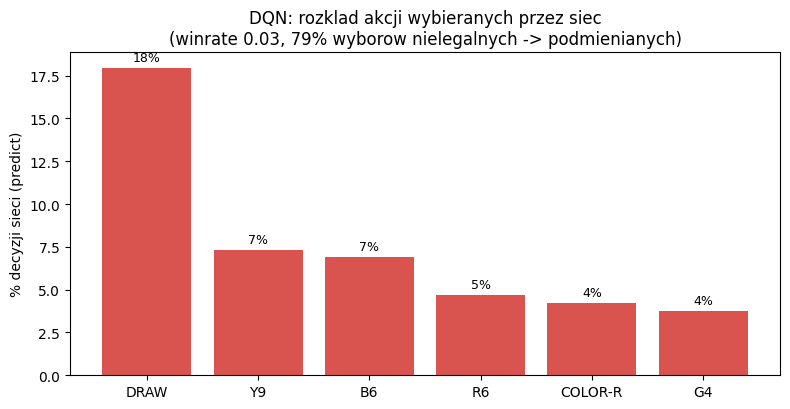

In [31]:
from collections import Counter

def _act_name(a):
    if a < 54: return card_name(a)
    if a == 54: return 'DRAW'
    return f'COLOR-{COLOR_NAMES[a-55]}'

# Diagnostyka: co wytrenowany DQN naprawdę robi w ewaluacji (deterministycznie) vs random.
# Rejestrujemy akcję WYBRANĄ przez sieć (predict) oraz faktycznie WYKONANĄ (po podmianie nielegalnych).
chosen, executed = Counter(), Counter()
illegal = total = wins = 0
diag_env = UnoGymEnv(opponent_policy=random_policy, seed=0)
for ep in range(200):
    obs, info = diag_env.reset(seed=ep)
    done = False; last_r = 0.0
    while not done:
        mask = info['action_mask']
        a_net = int(dqn.predict(obs, deterministic=True)[0])
        chosen[a_net] += 1; total += 1
        if not mask[a_net]:
            illegal += 1
            a_exec = int(np.random.choice(np.flatnonzero(mask)))
        else:
            a_exec = a_net
        executed[a_exec] += 1
        obs, r, done, _, info = diag_env.step(a_exec)
        last_r = r if r != 0 else last_r
    if last_r > 0: wins += 1

print(f'DQN winrate: {wins/200:.3f}')
print(f'Nielegalnych wyborow sieci: {illegal}/{total} ({100*illegal/total:.1f}%)')
print('\nTOP akcje, ktore siec CHCIALA zagrac (predict):')
for a, c in chosen.most_common(6):
    print(f'  {_act_name(a):>8}: {100*c/total:5.1f}%')
print('\nTOP akcje FAKTYCZNIE wykonane (po podmianie):')
for a, c in executed.most_common(6):
    print(f'  {_act_name(a):>8}: {100*c/total:5.1f}%')

top = chosen.most_common(6)
plt.figure(figsize=(8, 4.2))
bars = plt.bar([_act_name(a) for a, _ in top], [100*c/total for _, c in top], color='#d9534f')
plt.ylabel('% decyzji sieci (predict)')
plt.title(f'DQN: rozklad akcji wybieranych przez siec\n(winrate {wins/200:.2f}, {100*illegal/total:.0f}% wyborow nielegalnych -> podmienianych)')
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.4, f'{b.get_height():.0f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('dqn_action_dist.png', dpi=130); plt.show()

## 9. Krzywe uczenia — porównanie wszystkich modeli vs random

Wykres wymagany na 4 i 6 punktów.

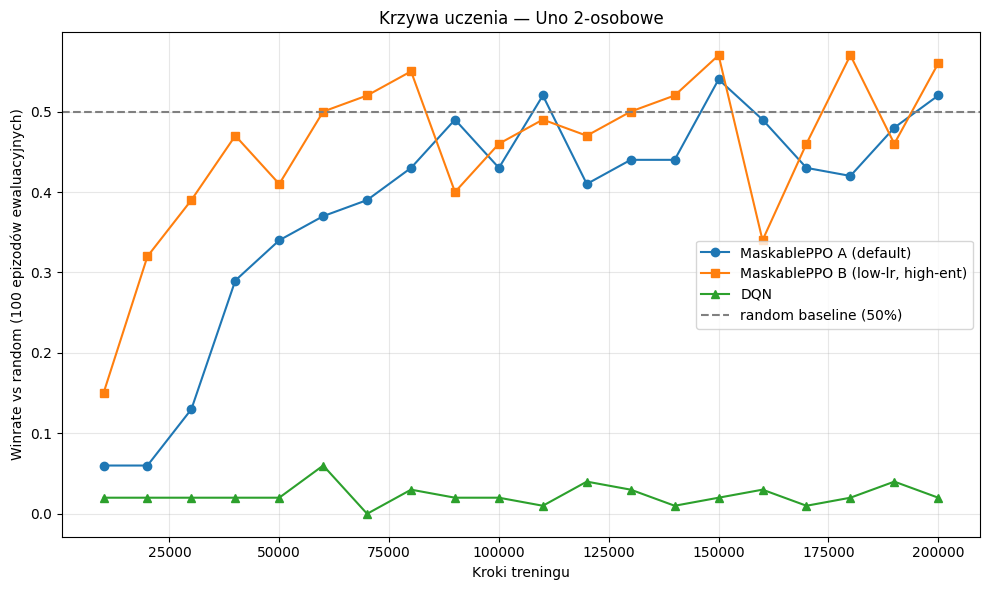

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(ppo_a_cb.timesteps, ppo_a_cb.winrates, marker='o', label='MaskablePPO A (default)')
plt.plot(ppo_b_cb.timesteps, ppo_b_cb.winrates, marker='s', label='MaskablePPO B (low-lr, high-ent)')
plt.plot(dqn_cb.timesteps, dqn_cb.winrates, marker='^', label='DQN')
plt.axhline(0.5, linestyle='--', color='gray', label='random baseline (50%)')
plt.xlabel('Kroki treningu')
plt.ylabel('Winrate vs random (100 epizodów ewaluacyjnych)')
plt.title('Krzywa uczenia — Uno 2-osobowe')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=130)
plt.show()

## 10. Eksperyment: self-play PPO (wszyscy agenci ten sam algorytm)

Trenujemy nowy MaskablePPO przeciw zamrożonej kopii samego siebie, aktualizowanej co `SELFPLAY_UPDATE_FREQ` kroków. To realizuje przypadek "wszyscy agenci w epizodzie używają tego samego algorytmu" (oba agenty to PPO, dzielący tę samą architekturę polityki).

In [33]:
SELFPLAY_UPDATE_FREQ = 25_000
SELFPLAY_TIMESTEPS = 200_000
SELFPLAY_SNAPSHOT_PATH = os.path.join(MODELS_DIR, 'ppo_selfplay_snapshot.zip')

class SelfPlayCallback(BaseCallback):
    def __init__(self, env: UnoGymEnv, update_freq: int, snapshot_path: str, verbose: int = 1):
        super().__init__(verbose)
        self.env = env
        self.update_freq = update_freq
        self.snapshot_path = snapshot_path
        self._last_update = 0

    def _on_step(self) -> bool:
        if self.num_timesteps - self._last_update >= self.update_freq:
            self._last_update = self.num_timesteps
            self.model.save(self.snapshot_path)
            opp_model = MaskablePPO.load(self.snapshot_path)
            self.env.set_opponent(policy_from_maskable(opp_model, deterministic=False))
            if self.verbose:
                print(f'  [selfplay] step={self.num_timesteps}: opponent snapshot updated')
        return True

selfplay_inner_env = UnoGymEnv(opponent_policy=random_policy, seed=SEED + 100)
selfplay_env = ActionMasker(selfplay_inner_env, lambda e: e.action_masks())
ppo_sp = MaskablePPO(
    'MlpPolicy', selfplay_env,
    learning_rate=3e-4, n_steps=2048, batch_size=64, n_epochs=10,
    gamma=0.99, gae_lambda=0.95, clip_range=0.2, ent_coef=0.01,
    verbose=0, tensorboard_log=LOG_DIR, seed=SEED + 100,
)
sp_cb = WinrateCallback('ppo', random_policy, eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL_EPISODES)
sp_update_cb = SelfPlayCallback(selfplay_inner_env, SELFPLAY_UPDATE_FREQ, SELFPLAY_SNAPSHOT_PATH)
ppo_sp.learn(total_timesteps=SELFPLAY_TIMESTEPS, callback=[sp_cb, sp_update_cb], tb_log_name='ppo_selfplay')
ppo_sp.save(os.path.join(MODELS_DIR, 'ppo_selfplay'))
print('PPO self-play: final winrate vs random =', sp_cb.winrates[-1] if sp_cb.winrates else 'n/a')

  [eval] step=  10000  winrate=0.090
  [eval] step=  20000  winrate=0.150
  [selfplay] step=25000: opponent snapshot updated
  [eval] step=  30000  winrate=0.260
  [eval] step=  40000  winrate=0.370
  [eval] step=  50000  winrate=0.360
  [selfplay] step=50000: opponent snapshot updated
  [eval] step=  60000  winrate=0.380
  [eval] step=  70000  winrate=0.530
  [selfplay] step=75000: opponent snapshot updated
  [eval] step=  80000  winrate=0.540
  [eval] step=  90000  winrate=0.490
  [eval] step= 100000  winrate=0.540
  [selfplay] step=100000: opponent snapshot updated
  [eval] step= 110000  winrate=0.520
  [eval] step= 120000  winrate=0.550
  [selfplay] step=125000: opponent snapshot updated
  [eval] step= 130000  winrate=0.530
  [eval] step= 140000  winrate=0.530
  [eval] step= 150000  winrate=0.590
  [selfplay] step=150000: opponent snapshot updated
  [eval] step= 160000  winrate=0.570
  [eval] step= 170000  winrate=0.570
  [selfplay] step=175000: opponent snapshot updated
  [eval] s

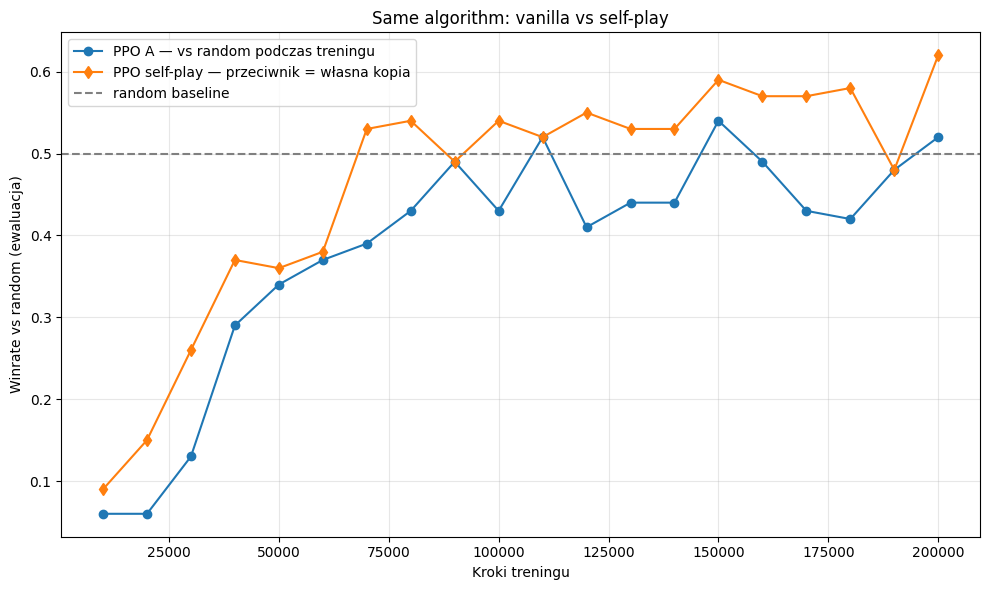

In [34]:
# Krzywa uczenia self-play vs vanilla PPO (oba ewaluowane vs random)
plt.figure(figsize=(10, 6))
plt.plot(ppo_a_cb.timesteps, ppo_a_cb.winrates, marker='o', label='PPO A — vs random podczas treningu')
plt.plot(sp_cb.timesteps, sp_cb.winrates, marker='d', label='PPO self-play — przeciwnik = własna kopia')
plt.axhline(0.5, linestyle='--', color='gray', label='random baseline')
plt.xlabel('Kroki treningu')
plt.ylabel('Winrate vs random (ewaluacja)')
plt.title('Same algorithm: vanilla vs self-play')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('selfplay_vs_vanilla.png', dpi=130)
plt.show()

## 11. Turniej: różne algorytmy w tym samym epizodzie

Każda para modeli rozgrywa N partii (przeciwnik z drugiej kolumny jest oponentem agenta z pierwszej). To realizuje przypadek "agenci w epizodzie używają różnych algorytmów". Wynik to winrate modelu z wiersza vs model z kolumny.

In [35]:
def pair_winrate(model_a, kind_a: str, model_b, kind_b: str, n_episodes: int = 200, seed: int = 0) -> float:
    """Model A gra przeciw modelowi B; zwraca winrate modelu A."""
    if kind_b == 'ppo':
        opp_policy = policy_from_maskable(model_b, deterministic=False)
    elif kind_b == 'dqn':
        opp_policy = policy_from_dqn(model_b, deterministic=True)
    elif kind_b == 'random':
        opp_policy = random_policy
    else:
        raise ValueError(kind_b)
    return evaluate_winrate(model_a, kind_a, opp_policy, n_episodes=n_episodes, seed=seed)

TOURNAMENT_EPISODES = 300
agents = [
    ('PPO_A',        ppo_a,  'ppo'),
    ('PPO_B',        ppo_b,  'ppo'),
    ('PPO_selfplay', ppo_sp, 'ppo'),
    ('DQN',          dqn,    'dqn'),
    ('Random',       None,   'random'),
]
names = [a[0] for a in agents]
n = len(agents)
results = np.full((n, n), np.nan)
print('Turniej (winrate wiersza vs kolumna, {} epizodów na parę):'.format(TOURNAMENT_EPISODES))
for i, (name_a, m_a, k_a) in enumerate(agents):
    for j, (name_b, m_b, k_b) in enumerate(agents):
        if i == j:
            continue
        if k_a == 'random':
            # random vs X: estimate by rolling out
            wins = 0
            if k_b == 'ppo':
                opp = policy_from_maskable(m_b, deterministic=False)
            elif k_b == 'dqn':
                opp = policy_from_dqn(m_b, deterministic=True)
            else:
                opp = random_policy
            ev = UnoGymEnv(opponent_policy=opp, seed=i*97 + j)
            for ep in range(TOURNAMENT_EPISODES):
                obs, info = ev.reset(seed=i*97 + j*131 + ep)
                done = False; last_r = 0.0
                while not done:
                    a = random_policy(obs, info['action_mask'])
                    obs, r, done, _, info = ev.step(a)
                    last_r = r if r != 0 else last_r
                if last_r > 0: wins += 1
            wr = wins / TOURNAMENT_EPISODES
        else:
            wr = pair_winrate(m_a, k_a, m_b, k_b, n_episodes=TOURNAMENT_EPISODES, seed=i*97 + j)
        results[i, j] = wr
        print(f'  {name_a:>14}  vs  {name_b:<14}  winrate = {wr:.3f}')

print('\nMacierz winrate (wiersz vs kolumna):')
print(' ' * 16 + '  '.join(f'{n:>10}' for n in names))
for i, row in enumerate(results):
    cells = ['     -    ' if np.isnan(v) else f'   {v:.3f}  ' for v in row]
    print(f'{names[i]:>14}  ' + '  '.join(cells))

Turniej (winrate wiersza vs kolumna, 300 epizodów na parę):
           PPO_A  vs  PPO_B           winrate = 0.480
           PPO_A  vs  PPO_selfplay    winrate = 0.500
           PPO_A  vs  DQN             winrate = 0.990
           PPO_A  vs  Random          winrate = 0.543
           PPO_B  vs  PPO_A           winrate = 0.500
           PPO_B  vs  PPO_selfplay    winrate = 0.450
           PPO_B  vs  DQN             winrate = 0.973
           PPO_B  vs  Random          winrate = 0.547
    PPO_selfplay  vs  PPO_A           winrate = 0.533
    PPO_selfplay  vs  PPO_B           winrate = 0.477
    PPO_selfplay  vs  DQN             winrate = 0.987
    PPO_selfplay  vs  Random          winrate = 0.487
             DQN  vs  PPO_A           winrate = 0.010
             DQN  vs  PPO_B           winrate = 0.010
             DQN  vs  PPO_selfplay    winrate = 0.020
             DQN  vs  Random          winrate = 0.017
          Random  vs  PPO_A           winrate = 0.513
          Random  vs  

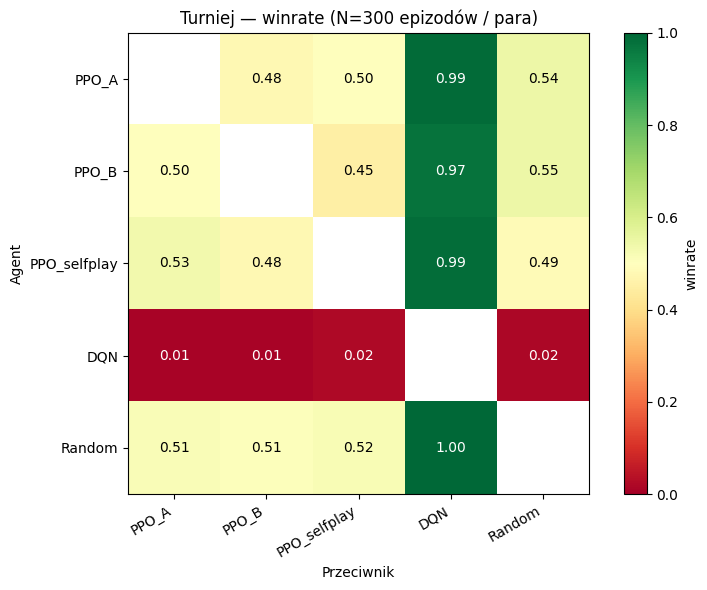

In [36]:
# Wizualizacja macierzy turniejowej
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(results, cmap='RdYlGn', vmin=0.0, vmax=1.0)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_yticklabels(names)
ax.set_xlabel('Przeciwnik'); ax.set_ylabel('Agent')
ax.set_title(f'Turniej — winrate (N={TOURNAMENT_EPISODES} epizodów / para)')
for i in range(n):
    for j in range(n):
        v = results[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='black' if 0.3 < v < 0.7 else 'white', fontsize=10)
fig.colorbar(im, ax=ax, label='winrate')
plt.tight_layout()
plt.savefig('tournament_matrix.png', dpi=130)
plt.show()

## 12. Podsumowanie liczbowe — do sprawozdania

Zbieramy kluczowe metryki: finalny winrate każdego modelu vs random, oraz średni winrate w turnieju (siła względna).

In [37]:
summary_rows = []
for i, name in enumerate(names):
    row_vals = [v for v in results[i] if not np.isnan(v)]
    avg_wr = float(np.mean(row_vals)) if row_vals else float('nan')
    summary_rows.append((name, avg_wr))

print('Średni winrate w turnieju (wyższy = silniejszy):')
for name, wr in sorted(summary_rows, key=lambda x: -x[1]):
    print(f'  {name:>14}  {wr:.3f}')

print('\nFinalne winrate vs random (z krzywej uczenia):')
for label, cb in [('PPO_A', ppo_a_cb), ('PPO_B', ppo_b_cb), ('DQN', dqn_cb), ('PPO_selfplay', sp_cb)]:
    last = cb.winrates[-1] if cb.winrates else float('nan')
    print(f'  {label:>14}  {last:.3f}')

Średni winrate w turnieju (wyższy = silniejszy):
          Random  0.633
           PPO_A  0.628
    PPO_selfplay  0.621
           PPO_B  0.617
             DQN  0.014

Finalne winrate vs random (z krzywej uczenia):
           PPO_A  0.520
           PPO_B  0.560
             DQN  0.020
    PPO_selfplay  0.620


## 13. Demo: rozgrywka krok po kroku

PPO_A (deterministycznie) vs random — można podejrzeć kilka ruchów.

In [38]:
demo_env = UnoGymEnv(opponent_policy=random_policy, seed=123)
obs, info = demo_env.reset(seed=123)
agent_policy = policy_from_maskable(ppo_a, deterministic=True)
step_count = 0
while step_count < 30:
    print(f'\n--- Step {step_count} ---')
    demo_env.render()
    a = agent_policy(obs, info['action_mask'])
    name = card_name(a) if a < 54 else ('DRAW' if a == 54 else f'CHOOSE-{COLOR_NAMES[a-55]}')
    print(f'  Agent (P{demo_env.agent_player}) plays: {name}')
    obs, r, done, _, info = demo_env.step(a)
    step_count += 1
    if done:
        print(f'\n=== GAME OVER. Final reward for agent = {r} ===')
        break


--- Step 0 ---
Turn 1 | Top: Y5 | Color: Y | Debt: 0
  P0 hand (6): ['B1', 'RRv', 'R3', 'B6', 'G+2', 'R6']
  P1 hand (7): ['Y0', 'B8', 'YRv', 'Y+2', 'B1', 'R8', 'B7']
  Agent is P1
  Agent (P1) plays: YRv

--- Step 1 ---
Turn 2 | Top: YRv | Color: Y | Debt: 0
  P0 hand (6): ['B1', 'RRv', 'R3', 'B6', 'G+2', 'R6']
  P1 hand (6): ['Y0', 'B8', 'Y+2', 'B1', 'R8', 'B7']
  Agent is P1
  Agent (P1) plays: Y+2

--- Step 2 ---
Turn 4 | Top: G+2 | Color: G | Debt: 4
  P0 hand (5): ['B1', 'RRv', 'R3', 'B6', 'R6']
  P1 hand (5): ['Y0', 'B8', 'B1', 'R8', 'B7']
  Agent is P1
  Agent (P1) plays: DRAW

--- Step 3 ---
Turn 6 | Top: G+2 | Color: G | Debt: 0
  P0 hand (6): ['B1', 'RRv', 'R3', 'B6', 'R6', 'YS']
  P1 hand (9): ['Y0', 'B8', 'B1', 'R8', 'B7', 'R4', 'R3', 'G6', 'B0']
  Agent is P1
  Agent (P1) plays: G6

--- Step 4 ---
Turn 8 | Top: B6 | Color: B | Debt: 0
  P0 hand (5): ['B1', 'RRv', 'R3', 'R6', 'YS']
  P1 hand (8): ['Y0', 'B8', 'B1', 'R8', 'B7', 'R4', 'R3', 'B0']
  Agent is P1
  Agent (P1) 

---
## Notatki do sprawozdania

Co warto omówić (2–3 strony A4):

1. **Środowisko**: zasady Uno, reprezentacja stanu (170-wymiarowy wektor), 59 akcji, action masking jako kluczowy mechanizm dla gier kartach.
2. **Architektura RL**: opakowanie 2-osobowej gry jako single-agent env z wymiennym przeciwnikiem; trening vs random jako podstawowa heurystyka.
3. **Algorytm główny (4 pkt)**: MaskablePPO — czemu policy gradient sprawdza się dla gier z maskowaniem akcji.
4. **Porównanie (6 pkt)**: 3 krzywe uczenia (PPO_A, PPO_B, DQN). DQN bez maskowania ma trudniej; PPO_B z większą eksploracją może uczyć się wolniej ale stabilniej.
5. **Same vs mixed (6 pkt)**: self-play (oba agenty PPO) vs turniej między różnymi algorytmami — czy PPO trenowany w self-play radzi sobie lepiej w grach z innymi modelami niż PPO trenowany tylko vs random?
6. **Własne środowisko (8 pkt)**: pełna implementacja od zera, ~300 linii silnika; uzasadnienie wyboru gry; ograniczenia (brak "Uno!", brak wymuszania).

Wszystkie wykresy zapisują się do plików `learning_curves.png`, `selfplay_vs_vanilla.png`, `tournament_matrix.png` — do wklejenia w raport.

Logi TensorBoard w `tb_logs/` — można pokazać dodatkowe metryki (policy loss, value loss, entropy, episode length).